# Monthly Sales Forecasting Analysis

Data entered as provided in the source spreadsheet.

**Data note:** the analysis brief specifies data ending in March 2025, but the raw table also shows April 2025 (4,700). The main forecast follows the specified cutoff and only uses data through March 2025. A sensitivity check at the end includes April 2025 to see if it changes anything.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
sales_df = pd.DataFrame({
    "Month": ["2023-01","2023-02","2023-03","2023-04","2023-05","2023-06",
              "2023-07","2023-08","2023-09","2023-10","2023-11","2023-12",
              "2024-01","2024-02","2024-03","2024-04","2024-05","2024-06",
              "2024-07","2024-08","2024-09","2024-10","2024-11","2024-12",
              "2025-01","2025-02","2025-03","2025-04"],
    "Sales": [2300,2200,2800,2900,4000,4500,3900,4900,4400,3900,3500,3300,
              3600,3800,4000,3900,4800,4900,5500,6200,4800,4700,4200,3800,
              4200,4500,5000,4700]
})
sales_df

,Month,Sales
0,2023-01,2300
1,2023-02,2200
2,2023-03,2800
3,2023-04,2900
4,2023-05,4000
5,2023-06,4500
6,2023-07,3900
7,2023-08,4900
8,2023-09,4400
9,2023-10,3900


In [3]:
sales_df["Month"] = pd.to_datetime(sales_df["Month"])
sales_df["Sales"] = pd.to_numeric(sales_df["Sales"])
sales_df = sales_df.sort_values("Month").reset_index(drop=True)

full_range = pd.date_range(sales_df["Month"].min(), sales_df["Month"].max(), freq="MS")

dq_summary = pd.DataFrame({
    "check": ["rows", "min month", "max month", "duplicate months", "missing values", "negative sales", "missing monthly periods"],
    "result": [len(sales_df),
               sales_df["Month"].min().strftime("%Y-%m"),
               sales_df["Month"].max().strftime("%Y-%m"),
               sales_df["Month"].duplicated().sum(),
               sales_df.isna().sum().sum(),
               (sales_df["Sales"] < 0).sum(),
               len(full_range) - sales_df["Month"].nunique()]
})
dq_summary

,check,result
0,rows,28
1,min month,2023-01
2,max month,2025-04
3,duplicate months,0
4,missing values,0
5,negative sales,0
6,missing monthly periods,0


In [4]:
sales_df

,Month,Sales
0,2023-01-01,2300
1,2023-02-01,2200
2,2023-03-01,2800
3,2023-04-01,2900
4,2023-05-01,4000
5,2023-06-01,4500
6,2023-07-01,3900
7,2023-08-01,4900
8,2023-09-01,4400
9,2023-10-01,3900


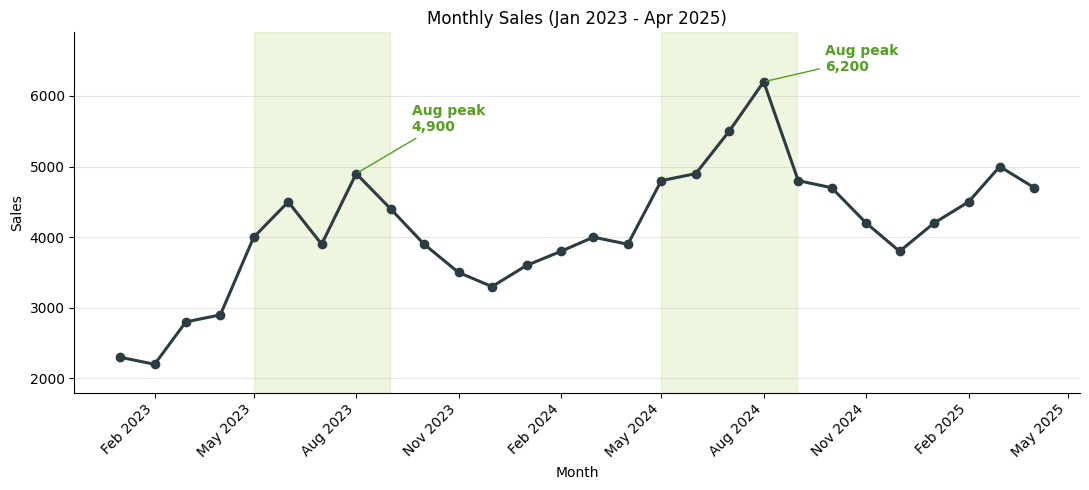

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(sales_df["Month"], sales_df["Sales"], marker="o", color="#2C3C43", linewidth=2.2)
# shade the May-Aug window each year so the summer build-up is easy to see
for yr in [2023, 2024]:
    ax.axvspan(pd.Timestamp(str(yr) + "-05-01"), pd.Timestamp(str(yr) + "-08-31"), color="#90C226", alpha=0.14)
ax.annotate("Aug peak\n4,900", xy=(pd.Timestamp("2023-08-01"), 4900),
            xytext=(pd.Timestamp("2023-09-20"), 5500), color="#54A021",
            fontweight="bold", arrowprops=dict(arrowstyle="-", color="#54A021"))
ax.annotate("Aug peak\n6,200", xy=(pd.Timestamp("2024-08-01"), 6200),
            xytext=(pd.Timestamp("2024-09-25"), 6350), color="#54A021",
            fontweight="bold", arrowprops=dict(arrowstyle="-", color="#54A021"))
ax.set_title("Monthly Sales (Jan 2023 - Apr 2025)")
ax.set_xlabel("Month")
ax.set_ylabel("Sales")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
for lbl in ax.get_xticklabels():
    lbl.set_rotation(45)
    lbl.set_ha("right")
ax.set_ylim(1800, 6900)
ax.grid(alpha=0.3, axis="y")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.set_facecolor("white")
ax.set_facecolor("white")
fig.savefig("chart_hist_allo.png", dpi=200, facecolor="white")

In [6]:
trend_df = sales_df.copy()
trend_df["mom_pct"] = trend_df["Sales"].pct_change() * 100
trend_df["yoy_pct"] = trend_df["Sales"].pct_change(12) * 100
trend_df["rolling_3m"] = trend_df["Sales"].rolling(3).mean()
trend_df["rolling_12m"] = trend_df["Sales"].rolling(12).mean()
trend_df.round(1).tail(12)

/tmp/ipykernel_598/3134710415.py:6: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  trend_df.round(1).tail(12)


,Month,Sales,mom_pct,yoy_pct,rolling_3m,rolling_12m
16,2024-05-01,4800,23.1,20.0,4233.3,4041.7
17,2024-06-01,4900,2.1,8.9,4533.3,4075.0
18,2024-07-01,5500,12.2,41.0,5066.7,4208.3
19,2024-08-01,6200,12.7,26.5,5533.3,4316.7
20,2024-09-01,4800,-22.6,9.1,5500.0,4350.0
21,2024-10-01,4700,-2.1,20.5,5233.3,4416.7
22,2024-11-01,4200,-10.6,20.0,4566.7,4475.0
23,2024-12-01,3800,-9.5,15.2,4233.3,4516.7
24,2025-01-01,4200,10.5,16.7,4066.7,4566.7
25,2025-02-01,4500,7.1,18.4,4166.7,4625.0


## Business insights from the historical data

- **Overall direction:** sales are clearly growing. Every month in 2024 came in above the same month in 2023, and Jan-Apr 2025 is running roughly 17-25% above the same months in 2024. The 12-month rolling average also rises steadily.
- **Possible seasonality:** both full years show the same shape - sales build through late spring, peak in the summer, then cool off going into winter.
- **Higher-sales months:** May through September. August is the single highest month in both 2023 (4,900) and 2024 (6,200).
- **Lower-sales months:** November through February. The lowest points are Feb 2023 (2,200) and the Dec/Jan area in both years.
- **Late spring and summer do look stronger, and late fall / winter looks softer**, consistently in both years.
- **What this might suggest about the business:** a summer peak with a winter dip would fit a business tied to household moves and installations (people move and set up service more in summer, less in winter). I am presenting that as an inference from the shape of the data, not a confirmed fact - I would want customer adds / install data to confirm it.
- **Confidence caveat:** we only have about two full annual cycles, so the seasonal pattern is based on just two observations of each month. It looks consistent, but it is a thin base.

In [7]:
# analysis brief specifies data through Mar 2025, so April is left out of the main model
main_df = sales_df[sales_df["Month"] <= "2025-03-01"].reset_index(drop=True)
main_df.tail(4)

,Month,Sales
23,2024-12-01,3800
24,2025-01-01,4200
25,2025-02-01,4500
26,2025-03-01,5000


**Holdout choice:** the last 3 months (Jan-Mar 2025) are used as the validation set, because Holt-Winters with 12-month seasonality needs at least two full years to train, which leaves exactly Jan 2023 - Dec 2024 (24 months) for training. A random split is not valid for time series, so the split is strictly by time.

In [8]:
train_df = main_df[main_df["Month"] <= "2024-12-01"].reset_index(drop=True)
test_df = main_df[main_df["Month"] >= "2025-01-01"].reset_index(drop=True)

train_sales = train_df.set_index("Month")["Sales"].asfreq("MS")
actual_sales = test_df["Sales"].values
test_df

,Month,Sales
0,2025-01-01,4200
1,2025-02-01,4500
2,2025-03-01,5000


In [9]:
snaive_pred = []
for m in test_df["Month"]:
    prev_year = m - pd.DateOffset(years=1)
    val = train_df.loc[train_df["Month"] == prev_year, "Sales"]
    snaive_pred.append(val.iloc[0] if len(val) > 0 else np.nan)
snaive_pred = np.array(snaive_pred, dtype=float)
snaive_pred

array([3600., 3800., 4000.])

In [10]:
holt_model = Holt(train_sales, initialization_method="estimated").fit()
holt_pred = holt_model.forecast(len(test_df)).values
holt_pred.round(1)

array([3888.1, 3954.5, 4021. ])

*Note: with only 24 training months (two seasonal cycles), the seasonal estimates below are usable but not very stable - this is acknowledged as a limitation.*

In [11]:
hw_model = ExponentialSmoothing(train_sales, trend="add", seasonal="add",
                                seasonal_periods=12,
                                initialization_method="estimated").fit()
hw_pred = hw_model.forecast(len(test_df)).values
hw_pred.round(1)

array([4400., 4450., 4850.])

In [12]:
train_X = pd.get_dummies(train_df["Month"].dt.month, prefix="m", dtype=float)
train_X["month_number"] = np.arange(len(train_df))

test_X = pd.get_dummies(test_df["Month"].dt.month, prefix="m", dtype=float)
for col in train_X.columns:
    if col not in test_X.columns:
        test_X[col] = 0.0
test_X["month_number"] = np.arange(len(train_df), len(train_df) + len(test_df))
test_X = test_X[train_X.columns]

lin_model = LinearRegression()
lin_model.fit(train_X, train_df["Sales"])
lin_pred = lin_model.predict(test_X)
lin_pred.round(1)

array([4400., 4450., 4850.])

In [13]:
def mae(actual, pred):
    return mean_absolute_error(actual, pred)

def rmse(actual, pred):
    return np.sqrt(mean_squared_error(actual, pred))

def mape(actual, pred):
    actual = np.array(actual, dtype=float)
    pred = np.array(pred, dtype=float)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100

In [14]:
model_preds = {
    "Seasonal Naive": snaive_pred,
    "Holt Linear Trend": holt_pred,
    "Holt-Winters Additive": hw_pred,
    "Linear Trend + Month Dummies": lin_pred
}

rows = []
for name, pred_sales in model_preds.items():
    rows.append({"Model": name,
                 "MAE_exact": mae(actual_sales, pred_sales),
                 "RMSE_exact": rmse(actual_sales, pred_sales),
                 "MAPE_exact": mape(actual_sales, pred_sales)})

# rank on the exact values, round only for display
model_results = pd.DataFrame(rows).sort_values("RMSE_exact").reset_index(drop=True)
model_results["MAE"] = model_results["MAE_exact"].round(1)
model_results["RMSE"] = model_results["RMSE_exact"].round(1)
model_results["MAPE"] = model_results["MAPE_exact"].round(2)
model_results = model_results[["Model", "MAE", "RMSE", "MAPE"]]
model_results

,Model,MAE,RMSE,MAPE
0,Holt-Winters Additive,133.3,147.2,2.96
1,Linear Trend + Month Dummies,133.3,147.2,2.96
2,Holt Linear Trend,612.1,671.7,13.04
3,Seasonal Naive,766.7,785.3,16.61


*Precision note: at full precision Holt-Winters edges the regression by ~0.002 MAE (133.3316 vs 133.3333) - but their actual predictions differ by less than 0.01 sales units, which is optimizer tolerance, not model skill. I treat them as tied on accuracy and select on interpretability and stability.*

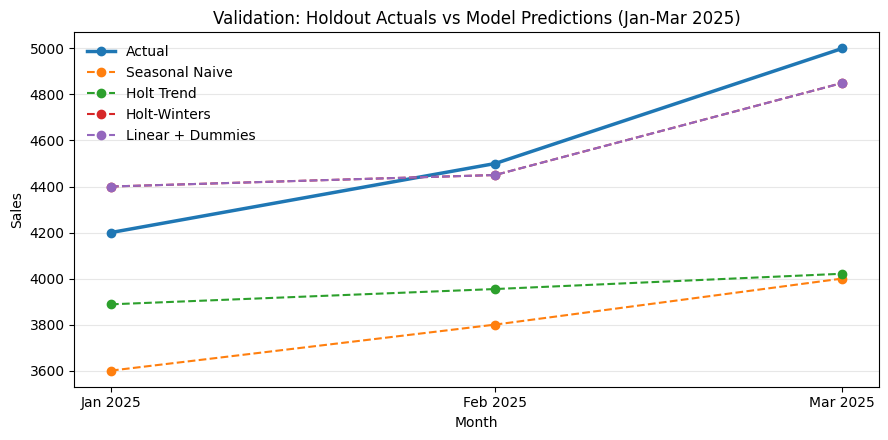

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(test_df["Month"], actual_sales, marker="o", linewidth=2.5, label="Actual")
ax.plot(test_df["Month"], snaive_pred, marker="o", linestyle="--", label="Seasonal Naive")
ax.plot(test_df["Month"], holt_pred, marker="o", linestyle="--", label="Holt Trend")
ax.plot(test_df["Month"], hw_pred, marker="o", linestyle="--", label="Holt-Winters")
ax.plot(test_df["Month"], lin_pred, marker="o", linestyle="--", label="Linear + Dummies")
ax.set_title("Validation: Holdout Actuals vs Model Predictions (Jan-Mar 2025)")
ax.set_xlabel("Month")
ax.set_ylabel("Sales")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.legend(frameon=False)
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()

## Final model selection

**Selected model: Holt-Winters (additive trend, additive seasonality).**

Reasoning:
- **Validation accuracy:** Holt-Winters and the linear-trend-with-month-dummies regression tie for best on the holdout (MAPE ~3%), and both are roughly 5x better than the seasonal naive baseline. Holt's trend-only model misses the seasonality, which confirms seasonality matters here.
- **Interpretability:** Holt-Winters decomposes into level + trend + monthly seasonal effects, which maps directly onto what the chart shows and is easy to explain to a business audience.
- **Stability:** the fact that a completely different method (the regression) lands on the same numbers means the result is driven by the data pattern, not by one model's quirks.
- **Business plausibility:** forecasts keep the summer peak / winter dip shape and continue the observed growth, with nothing exotic.

I am deliberately not chasing a marginally better metric with a more complex model - with 27 data points, simple and explainable wins.

In [16]:
main_sales = main_df.set_index("Month")["Sales"].asfreq("MS")
final_model = ExponentialSmoothing(main_sales, trend="add", seasonal="add",
                                   seasonal_periods=12,
                                   initialization_method="estimated").fit()

In [17]:
future_dates = pd.date_range("2025-04-01", "2026-12-01", freq="MS")
pred_sales = final_model.forecast(len(future_dates)).clip(lower=0)

forecast_df = pd.DataFrame({
    "Month": future_dates.strftime("%Y-%m"),
    "Forecast_Sales": pred_sales.round(0).astype(int).values,
    "Model": "Holt-Winters additive"
})
forecast_df

,Month,Forecast_Sales,Model
0,2025-04,4850,Holt-Winters additive
1,2025-05,5850,Holt-Winters additive
2,2025-06,6150,Holt-Winters additive
3,2025-07,6150,Holt-Winters additive
4,2025-08,7000,Holt-Winters additive
5,2025-09,6050,Holt-Winters additive
6,2025-10,5750,Holt-Winters additive
7,2025-11,5300,Holt-Winters additive
8,2025-12,5000,Holt-Winters additive
9,2026-01,5300,Holt-Winters additive


In [18]:
fy2025_total = sales_df.loc[(sales_df["Month"] >= "2025-01-01") & (sales_df["Month"] <= "2025-03-01"), "Sales"].sum() + pred_sales.loc["2025-04":"2025-12"].sum()
fy2026_total = pred_sales.loc["2026-01":"2026-12"].sum()
fy2024_total = sales_df.loc[(sales_df["Month"] >= "2024-01-01") & (sales_df["Month"] <= "2024-12-01"), "Sales"].sum()

fy2024_vals = sales_df.loc[(sales_df["Month"] >= "2024-01-01") & (sales_df["Month"] <= "2024-12-01"), "Sales"]
fy2025_vals = pd.concat([sales_df.loc[(sales_df["Month"] >= "2025-01-01") & (sales_df["Month"] <= "2025-03-01"), "Sales"], pred_sales.loc["2025-04":"2025-12"]])
fy2026_vals = pred_sales.loc["2026-01":"2026-12"]

forecast_summary_df = pd.DataFrame({
    "Period": ["FY2024 (actual)", "FY2025 (actual Jan-Mar + forecast)", "FY2026 (forecast)"],
    "Total_Sales": [int(fy2024_total), int(round(fy2025_total)), int(round(fy2026_total))],
    "Avg_Month": [int(round(fy2024_vals.mean())), int(round(fy2025_vals.mean())), int(round(fy2026_vals.mean()))],
    "Min_Month": [int(round(fy2024_vals.min())), int(round(fy2025_vals.min())), int(round(fy2026_vals.min()))],
    "Max_Month": [int(round(fy2024_vals.max())), int(round(fy2025_vals.max())), int(round(fy2026_vals.max()))],
    "Growth_vs_Prior": ["-", str(round(100 * (fy2025_total - fy2024_total) / fy2024_total, 1)) + "%", str(round(100 * (fy2026_total - fy2025_total) / fy2025_total, 1)) + "%"]
})
forecast_summary_df

,Period,Total_Sales,Avg_Month,Min_Month,Max_Month,Growth_vs_Prior
0,FY2024 (actual),54200,4517,3600,6200,-
1,FY2025 (actual Jan-Mar + forecast),65800,5483,4200,7000,21.4%
2,FY2026 (forecast),77400,6450,5300,7967,17.6%


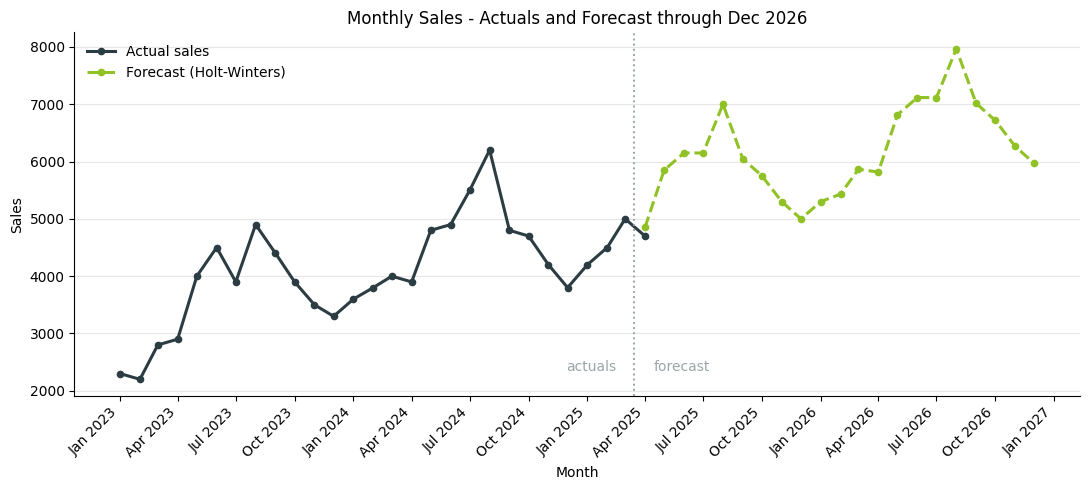

In [19]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(sales_df["Month"], sales_df["Sales"], marker="o", color="#2C3C43",
        linewidth=2.2, markersize=4.5, label="Actual sales")
ax.plot(future_dates, pred_sales.values, marker="o", color="#90C226", linestyle="--",
        linewidth=2.2, markersize=4.5, label="Forecast (Holt-Winters)")
ax.axvline(pd.Timestamp("2025-03-15"), color="#9AA5A8", linestyle=":", linewidth=1.4)
ax.text(pd.Timestamp("2025-02-15"), 2350, "actuals", ha="right", color="#9AA5A8")
ax.text(pd.Timestamp("2025-04-15"), 2350, "forecast", color="#9AA5A8")
ax.set_title("Monthly Sales - Actuals and Forecast through Dec 2026")
ax.set_xlabel("Month")
ax.set_ylabel("Sales")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
for lbl in ax.get_xticklabels():
    lbl.set_rotation(45)
    lbl.set_ha("right")
ax.legend(frameon=False, loc="upper left")
ax.grid(alpha=0.3, axis="y")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.set_facecolor("white")
ax.set_facecolor("white")
fig.savefig("chart_fc_allo.png", dpi=200, facecolor="white")

In [20]:
model_results.to_csv("model_comparison.csv", index=False)
forecast_df.to_csv("sales_forecast_through_dec_2026.csv", index=False)

hist_out = sales_df.copy()
hist_out["Month"] = hist_out["Month"].dt.strftime("%Y-%m")
with pd.ExcelWriter("sales_forecast_output.xlsx") as writer:
    hist_out.to_excel(writer, sheet_name="Historical Data", index=False)
    model_results.to_excel(writer, sheet_name="Model Comparison", index=False)
    forecast_df.to_excel(writer, sheet_name="Forecast", index=False)
    forecast_summary_df.to_excel(writer, sheet_name="Summary", index=False)

# widen columns and bold headers so the workbook is readable as-is
from openpyxl import load_workbook
from openpyxl.styles import Font
wb = load_workbook("sales_forecast_output.xlsx")
for ws in wb.worksheets:
    for column_cells in ws.columns:
        longest = max(len(str(c.value)) if c.value is not None else 0 for c in column_cells)
        ws.column_dimensions[column_cells[0].column_letter].width = longest + 3
    for c in ws[1]:
        c.font = Font(bold=True)
wb.save("sales_forecast_output.xlsx")

generated_files_df = pd.DataFrame({"file": ["model_comparison.csv",
                                            "sales_forecast_through_dec_2026.csv",
                                            "sales_forecast_output.xlsx"]})
generated_files_df

,file
0,model_comparison.csv
1,sales_forecast_through_dec_2026.csv
2,sales_forecast_output.xlsx


## Sensitivity check - what if April 2025 is included?

In [21]:
sens_sales = sales_df.set_index("Month")["Sales"].asfreq("MS")
sens_model = ExponentialSmoothing(sens_sales, trend="add", seasonal="add",
                                  seasonal_periods=12,
                                  initialization_method="estimated").fit()

sens_dates = pd.date_range("2025-05-01", "2026-12-01", freq="MS")
sens_pred = sens_model.forecast(len(sens_dates)).clip(lower=0)

sens_df = pd.DataFrame({"Month": sens_dates.strftime("%Y-%m"),
                        "April_Included_Forecast": sens_pred.round(0).astype(int).values})

compare_df = forecast_df[["Month", "Forecast_Sales"]].rename(columns={"Forecast_Sales": "Primary_Forecast"})
compare_df = compare_df.merge(sens_df, on="Month", how="inner")
compare_df["Difference"] = compare_df["April_Included_Forecast"] - compare_df["Primary_Forecast"]
compare_df["Difference_Percent"] = (100 * compare_df["Difference"] / compare_df["Primary_Forecast"]).round(2)
compare_df

,Month,Primary_Forecast,April_Included_Forecast,Difference,Difference_Percent
0,2025-05,5850,5831,-19,-0.32
1,2025-06,6150,6131,-19,-0.31
2,2025-07,6150,6131,-19,-0.31
3,2025-08,7000,6981,-19,-0.27
4,2025-09,6050,6031,-19,-0.31
5,2025-10,5750,5731,-19,-0.33
6,2025-11,5300,5281,-19,-0.36
7,2025-12,5000,4981,-19,-0.38
8,2026-01,5300,5275,-25,-0.47
9,2026-02,5433,5408,-25,-0.46


**Takeaway:** including April 2025 shifts the overlapping months by 19-75 sales units: 2025 months move ~19 (~0.3%), most 2026 months move 25-32 (~0.4-0.5%), and a single month - April 2026 - moves 75 (1.3%). The FY2026 total shifts by about 0.5%. So the March-vs-April discrepancy is immaterial to the model choice, the seasonal shape, and the annual picture - but the month-level differences are worth stating precisely. As a bonus check, the primary model (which never saw April) forecast April 2025 at 4,850 vs the actual 4,700 in the table - about a 3% miss, in line with validation accuracy.

## Additional data that would improve the forecast

- **New customers (gross adds):** sales = customers x value. Forecasting adds directly, instead of a blended sales line, ties the forecast to the real growth driver.
- **Customer churn:** separates growth from retention. If churn is rising, a sales-only forecast overstates the future.
- **Homes passed / service availability:** fiber sales are capped by where the network exists. This acts as a ceiling so the model does not project growth into markets that are not built yet.
- **Geographic expansion plans:** new market launches create step-jumps no time-series model can anticipate. Knowing launch dates turns surprises into planned inputs.
- **Product mix:** internet, TV and phone can trend differently. Forecasting each line and summing is usually more accurate than forecasting the blended total.
- **Pricing changes:** a price increase can raise revenue while units fall. Price history separates rate effects from real demand.
- **Promotions:** promo months look like seasonal spikes but are not. Flagging them keeps one-off lifts out of the seasonal estimate.
- **Marketing campaigns:** campaign spend and timing is a leading indicator of demand and explains month-to-month bumps that otherwise look like noise.
- **Installation capacity:** if installs are the bottleneck in summer, recorded sales understate demand. Capacity data tells us whether peaks are demand-limited or supply-limited.
- **Sales pipeline:** pending orders are the best short-horizon signal and would sharpen the next 1-3 months of the forecast.
- **Competitor activity:** a competitor entering or discounting shifts the trend. Even a simple event flag helps explain residual dips.
- **Weather:** installation work is weather-constrained, so an unusually harsh winter creates low outliers the model would otherwise learn as seasonality.
- **Economic conditions:** housing starts, moves and local employment drive household formation, and help split company performance from market tide.
- **Holidays / calendar effects:** business-day counts and holiday timing shift monthly totals; adjusting for them removes artificial month-to-month noise.
- **One-time events:** outages, migrations or system changes create outliers that should be labeled and excluded from trend and seasonal estimation.